# Mixed line and curve vectorisation

Classical vectorisation pipeline for images containing straight lines and curves.

Pipeline:

```text
threshold image → skeletonise → trace skeleton branches → fit each branch as line / circular arc / polyline → rasterise fitted vectors → compare with original
```

The notebook is self-contained. It will use `X_test` if it already exists in your kernel; otherwise it generates synthetic mixed line/curve samples.

In [1]:
# Uncomment this cell if one of these packages is missing.
# !pip install opencv-python scikit-image scipy

import json
import math
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
from skimage.morphology import skeletonize, binary_dilation, disk
from skimage.measure import approximate_polygon

np.random.seed(7)
random.seed(7)

IMG_SIZE = 64
LINE_WIDTH = 1
FOREGROUND_THRESHOLD = 0.5

DEFAULT_VECTORISE_PARAMS = {
    "min_path_points": 5,
    "line_rmse_max": 0.65,
    "line_relative_rmse_max": 0.035,
    "arc_rmse_max": 0.80,
    "arc_min_span_degrees": 12.0,
    "arc_max_radius": IMG_SIZE * 3.0,
    "polyline_tolerance": 1.2,
    "min_primitive_length": 5.0,
    "snap_angle_degrees": None,
    "snap_distance": 1.5,
}


## Synthetic mixed sample generator

This is only for testing the vectoriser. You can replace the sample image with your own raster image later.

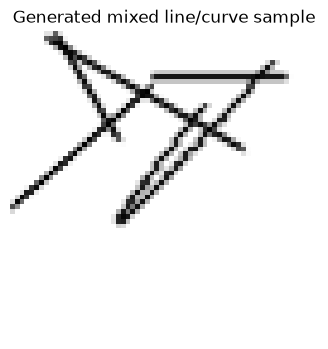

[{'type': 'line', 'x1': 29, 'y1': 11, 'x2': 0, 'y2': 36},
 {'type': 'line', 'x1': 7, 'y1': 1, 'x2': 48, 'y2': 24},
 {'type': 'line', 'x1': 29, 'y1': 9, 'x2': 57, 'y2': 9}]

In [2]:
def normalise_image(image):
    image = np.asarray(image).squeeze()

    if image.ndim == 3:
        image = image[:, :, 0]

    image = image.astype("float32")

    if image.max() > 1.0:
        image = image / 255.0

    return image


def draw_random_line(canvas, img_size=64, line_width=1):
    margin = 5
    x1 = np.random.randint(margin, img_size - margin)
    y1 = np.random.randint(margin, img_size - margin)

    angle = np.random.choice([0, 30, 45, 60, 90, 120, 135, 150])
    length = np.random.randint(img_size // 3, img_size - 10)

    dx = math.cos(math.radians(angle)) * length / 2
    dy = math.sin(math.radians(angle)) * length / 2

    p1 = (int(np.clip(x1 - dx, 0, img_size - 1)), int(np.clip(y1 - dy, 0, img_size - 1)))
    p2 = (int(np.clip(x1 + dx, 0, img_size - 1)), int(np.clip(y1 + dy, 0, img_size - 1)))

    cv2.line(canvas, p1, p2, color=0, thickness=line_width, lineType=cv2.LINE_AA)

    return {
        "type": "line",
        "x1": p1[0],
        "y1": p1[1],
        "x2": p2[0],
        "y2": p2[1],
    }


def draw_random_arc(canvas, img_size=64, line_width=1):
    radius = np.random.randint(10, 24)
    cx = np.random.randint(radius + 3, img_size - radius - 3)
    cy = np.random.randint(radius + 3, img_size - radius - 3)

    start = np.random.randint(0, 300)
    extent = np.random.randint(45, 150)
    end = start + extent

    cv2.ellipse(
        canvas,
        center=(int(cx), int(cy)),
        axes=(int(radius), int(radius)),
        angle=0,
        startAngle=float(start),
        endAngle=float(end),
        color=0,
        thickness=line_width,
        lineType=cv2.LINE_AA,
    )

    return {
        "type": "arc",
        "cx": float(cx),
        "cy": float(cy),
        "radius": float(radius),
        "start_degrees": float(start),
        "end_degrees": float(end),
    }


def cubic_bezier(p0, p1, p2, p3, n=80):
    t = np.linspace(0.0, 1.0, n)[:, None]
    p0 = np.asarray(p0, dtype="float32")
    p1 = np.asarray(p1, dtype="float32")
    p2 = np.asarray(p2, dtype="float32")
    p3 = np.asarray(p3, dtype="float32")

    points = (
        ((1 - t) ** 3) * p0
        + 3 * ((1 - t) ** 2) * t * p1
        + 3 * (1 - t) * (t ** 2) * p2
        + (t ** 3) * p3
    )

    return points


def draw_random_bezier(canvas, img_size=64, line_width=1):
    margin = 6
    p0 = np.array([np.random.randint(margin, img_size - margin), np.random.randint(margin, img_size - margin)])
    p3 = np.array([np.random.randint(margin, img_size - margin), np.random.randint(margin, img_size - margin)])
    p1 = np.array([np.random.randint(margin, img_size - margin), np.random.randint(margin, img_size - margin)])
    p2 = np.array([np.random.randint(margin, img_size - margin), np.random.randint(margin, img_size - margin)])

    points = cubic_bezier(p0, p1, p2, p3, n=100)
    points_int = np.round(points).astype(np.int32).reshape((-1, 1, 2))

    cv2.polylines(canvas, [points_int], isClosed=False, color=0, thickness=line_width, lineType=cv2.LINE_AA)

    return {
        "type": "bezier",
        "p0": p0.tolist(),
        "p1": p1.tolist(),
        "p2": p2.tolist(),
        "p3": p3.tolist(),
    }


def generate_mixed_sample(img_size=64, line_width=1, min_shapes=2, max_shapes=5):
    canvas = np.ones((img_size, img_size), dtype=np.uint8) * 255
    true_primitives = []

    n_shapes = np.random.randint(min_shapes, max_shapes + 1)
    shape_choices = ["line", "arc", "bezier"]
    shape_probs = [0.50, 0.35, 0.15]

    for _ in range(n_shapes):
        shape_type = np.random.choice(shape_choices, p=shape_probs)

        if shape_type == "line":
            true_primitives.append(draw_random_line(canvas, img_size, line_width))
        elif shape_type == "arc":
            true_primitives.append(draw_random_arc(canvas, img_size, line_width))
        else:
            true_primitives.append(draw_random_bezier(canvas, img_size, line_width))

    image = canvas.astype("float32") / 255.0
    return image, true_primitives


sample_image, sample_truth = generate_mixed_sample(IMG_SIZE, LINE_WIDTH)

plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap="gray", vmin=0, vmax=1)
plt.title("Generated mixed line/curve sample")
plt.axis("off")
plt.show()

sample_truth[:3]


## Skeleton tracing

The skeleton converts thick or antialiased strokes into one-pixel-wide graph paths. Branches are then traced between endpoints and junctions.

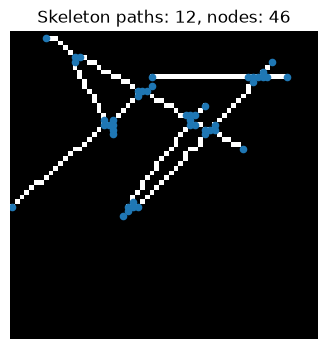

In [3]:
NEIGHBOUR_OFFSETS_8 = [
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1),           (0, 1),
    (1, -1),  (1, 0),  (1, 1),
]


def image_to_foreground(image, threshold=FOREGROUND_THRESHOLD):
    image = normalise_image(image)
    return image < threshold


def skeletonise_image(image, threshold=FOREGROUND_THRESHOLD):
    foreground = image_to_foreground(image, threshold=threshold)
    return skeletonize(foreground)


def get_neighbours(pixel, pixel_set):
    y, x = pixel
    neighbours = []

    for dy, dx in NEIGHBOUR_OFFSETS_8:
        candidate = (y + dy, x + dx)
        if candidate in pixel_set:
            neighbours.append(candidate)

    return neighbours


def trace_skeleton_paths(skeleton, min_path_points=5):
    ys, xs = np.nonzero(skeleton)
    pixels = set(zip(ys.tolist(), xs.tolist()))

    if not pixels:
        return [], set()

    degrees = {pixel: len(get_neighbours(pixel, pixels)) for pixel in pixels}
    nodes = {pixel for pixel, degree in degrees.items() if degree != 2}

    visited_edges = set()
    paths = []

    def edge_key(a, b):
        return tuple(sorted([a, b]))

    def mark_edge(a, b):
        visited_edges.add(edge_key(a, b))

    def edge_visited(a, b):
        return edge_key(a, b) in visited_edges

    for node in list(nodes):
        for first_neighbour in get_neighbours(node, pixels):
            if edge_visited(node, first_neighbour):
                continue

            path = [node, first_neighbour]
            mark_edge(node, first_neighbour)

            previous_pixel = node
            current_pixel = first_neighbour

            while current_pixel not in nodes:
                next_candidates = [
                    neighbour
                    for neighbour in get_neighbours(current_pixel, pixels)
                    if neighbour != previous_pixel
                ]

                if not next_candidates:
                    break

                next_pixel = next_candidates[0]

                if edge_visited(current_pixel, next_pixel):
                    break

                path.append(next_pixel)
                mark_edge(current_pixel, next_pixel)

                previous_pixel = current_pixel
                current_pixel = next_pixel

            if len(path) >= min_path_points:
                paths.append(path)

    # Closed loops can have no endpoint or junction, so every pixel has degree 2.
    # This catches any unvisited cycle edges.
    for pixel in list(pixels):
        for first_neighbour in get_neighbours(pixel, pixels):
            if edge_visited(pixel, first_neighbour):
                continue

            path = [pixel, first_neighbour]
            mark_edge(pixel, first_neighbour)

            start_pixel = pixel
            previous_pixel = pixel
            current_pixel = first_neighbour

            for _ in range(len(pixels) + 5):
                next_candidates = [
                    neighbour
                    for neighbour in get_neighbours(current_pixel, pixels)
                    if neighbour != previous_pixel
                ]

                if not next_candidates:
                    break

                next_pixel = next_candidates[0]

                if next_pixel == start_pixel:
                    path.append(next_pixel)
                    mark_edge(current_pixel, next_pixel)
                    break

                if edge_visited(current_pixel, next_pixel):
                    break

                path.append(next_pixel)
                mark_edge(current_pixel, next_pixel)

                previous_pixel = current_pixel
                current_pixel = next_pixel

            if len(path) >= min_path_points:
                paths.append(path)

    return paths, nodes


def path_pixels_to_xy(path):
    return np.array([[x, y] for y, x in path], dtype="float32")


skeleton = skeletonise_image(sample_image)
paths, nodes = trace_skeleton_paths(skeleton, min_path_points=DEFAULT_VECTORISE_PARAMS["min_path_points"])

plt.figure(figsize=(4, 4))
plt.imshow(skeleton, cmap="gray")
plt.scatter([x for y, x in nodes], [y for y, x in nodes], s=20)
plt.title(f"Skeleton paths: {len(paths)}, nodes: {len(nodes)}")
plt.axis("off")
plt.show()


## Primitive fitting

Each traced branch is fitted as one of these primitives:

```text
line      → if the path is almost straight
arc       → if a circle fits the path well
polyline  → fallback for arbitrary curves
```

In [4]:
def path_length(points):
    points = np.asarray(points, dtype="float32")

    if len(points) < 2:
        return 0.0

    return float(np.sum(np.linalg.norm(np.diff(points, axis=0), axis=1)))


def fit_line_to_points(points):
    points = np.asarray(points, dtype="float32")

    if len(points) < 2:
        return None

    centroid = np.mean(points, axis=0)
    centred = points - centroid

    _, _, vh = np.linalg.svd(centred, full_matrices=False)
    direction = vh[0]
    direction = direction / (np.linalg.norm(direction) + 1e-8)

    projections = centred @ direction
    p1 = centroid + projections.min() * direction
    p2 = centroid + projections.max() * direction

    perpendicular = centred - np.outer(projections, direction)
    distances = np.linalg.norm(perpendicular, axis=1)
    rmse = float(np.sqrt(np.mean(distances ** 2)))
    length = float(np.linalg.norm(p2 - p1))

    return {
        "type": "line",
        "x1": float(p1[0]),
        "y1": float(p1[1]),
        "x2": float(p2[0]),
        "y2": float(p2[1]),
        "rmse": rmse,
        "length": length,
    }


def fit_circle_arc_to_points(points):
    points = np.asarray(points, dtype="float32")

    if len(points) < 5:
        return None

    x = points[:, 0]
    y = points[:, 1]

    A = np.column_stack([2 * x, 2 * y, np.ones_like(x)])
    b = x ** 2 + y ** 2

    try:
        cx, cy, c = np.linalg.lstsq(A, b, rcond=None)[0]
    except np.linalg.LinAlgError:
        return None

    radius_squared = cx ** 2 + cy ** 2 + c

    if radius_squared <= 0:
        return None

    radius = float(np.sqrt(radius_squared))
    distances = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    rmse = float(np.sqrt(np.mean((distances - radius) ** 2)))

    raw_angles = np.arctan2(y - cy, x - cx)
    unwrapped_angles = np.unwrap(raw_angles)

    start_angle = float(unwrapped_angles[0])
    end_angle = float(unwrapped_angles[-1])
    span_degrees = float(abs(np.degrees(end_angle - start_angle)))

    return {
        "type": "arc",
        "cx": float(cx),
        "cy": float(cy),
        "radius": radius,
        "start_angle": start_angle,
        "end_angle": end_angle,
        "span_degrees": span_degrees,
        "rmse": rmse,
        "length": radius * abs(end_angle - start_angle),
    }


def simplify_polyline(points, tolerance=1.2):
    points = np.asarray(points, dtype="float32")

    if len(points) <= 2:
        simplified = points
    else:
        simplified = approximate_polygon(points, tolerance=tolerance)

    if len(simplified) == 0:
        simplified = points

    cleaned = [simplified[0]]

    for point in simplified[1:]:
        if np.linalg.norm(point - cleaned[-1]) > 0.5:
            cleaned.append(point)

    simplified = np.asarray(cleaned, dtype="float32")

    if len(simplified) == 1 and len(points) >= 2:
        simplified = np.array([points[0], points[-1]], dtype="float32")

    return {
        "type": "polyline",
        "points": simplified.tolist(),
        "length": path_length(simplified),
        "point_count": int(len(simplified)),
    }


def snap_line_angle(line, snap_angle_degrees=None):
    if snap_angle_degrees is None:
        return line

    x1, y1, x2, y2 = line["x1"], line["y1"], line["x2"], line["y2"]
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0
    length = math.hypot(x2 - x1, y2 - y1)

    angle = math.degrees(math.atan2(y2 - y1, x2 - x1)) % 180.0
    snapped_angle = round(angle / snap_angle_degrees) * snap_angle_degrees
    radians = math.radians(snapped_angle)

    dx = math.cos(radians) * length / 2.0
    dy = math.sin(radians) * length / 2.0

    line = dict(line)
    line["x1"] = cx - dx
    line["y1"] = cy - dy
    line["x2"] = cx + dx
    line["y2"] = cy + dy
    line["snapped_angle"] = snapped_angle

    return line


def fit_primitive(points, params=None):
    if params is None:
        params = DEFAULT_VECTORISE_PARAMS

    points = np.asarray(points, dtype="float32")

    if len(points) < params["min_path_points"]:
        return None

    branch_length = path_length(points)

    if branch_length < params["min_primitive_length"]:
        return None

    line = fit_line_to_points(points)

    if line is not None:
        relative_rmse = line["rmse"] / max(line["length"], 1e-6)

        if (
            line["rmse"] <= params["line_rmse_max"]
            or relative_rmse <= params["line_relative_rmse_max"]
        ):
            return snap_line_angle(line, params.get("snap_angle_degrees"))

    arc = fit_circle_arc_to_points(points)

    if arc is not None:
        if (
            arc["rmse"] <= params["arc_rmse_max"]
            and arc["span_degrees"] >= params["arc_min_span_degrees"]
            and arc["radius"] <= params["arc_max_radius"]
        ):
            return arc

    return simplify_polyline(points, tolerance=params["polyline_tolerance"])


## Snap primitive endpoints

This keeps intersections and near-touching endpoints cleaner after fitting.

In [5]:
def get_primitive_endpoints(primitive):
    if primitive["type"] == "line":
        return [
            np.array([primitive["x1"], primitive["y1"]], dtype="float32"),
            np.array([primitive["x2"], primitive["y2"]], dtype="float32"),
        ]

    if primitive["type"] == "arc":
        cx = primitive["cx"]
        cy = primitive["cy"]
        radius = primitive["radius"]
        start = primitive["start_angle"]
        end = primitive["end_angle"]

        return [
            np.array([cx + radius * math.cos(start), cy + radius * math.sin(start)], dtype="float32"),
            np.array([cx + radius * math.cos(end), cy + radius * math.sin(end)], dtype="float32"),
        ]

    if primitive["type"] == "polyline":
        points = np.asarray(primitive["points"], dtype="float32")
        return [points[0], points[-1]]

    return []


def set_primitive_endpoint(primitive, endpoint_index, new_point):
    primitive = dict(primitive)
    x, y = float(new_point[0]), float(new_point[1])

    if primitive["type"] == "line":
        if endpoint_index == 0:
            primitive["x1"] = x
            primitive["y1"] = y
        else:
            primitive["x2"] = x
            primitive["y2"] = y

    elif primitive["type"] == "polyline":
        points = np.asarray(primitive["points"], dtype="float32")
        points[endpoint_index if endpoint_index == 0 else -1] = [x, y]
        primitive["points"] = points.tolist()

    elif primitive["type"] == "arc":
        cx = primitive["cx"]
        cy = primitive["cy"]

        new_angle = math.atan2(y - cy, x - cx)

        if endpoint_index == 0:
            primitive["start_angle"] = new_angle
        else:
            primitive["end_angle"] = new_angle

    return primitive


def snap_near_endpoints(primitives, snap_distance=1.5):
    if not primitives:
        return primitives

    endpoint_records = []

    for primitive_index, primitive in enumerate(primitives):
        endpoints = get_primitive_endpoints(primitive)

        for endpoint_index, point in enumerate(endpoints):
            endpoint_records.append({
                "primitive_index": primitive_index,
                "endpoint_index": endpoint_index,
                "point": point,
            })

    if len(endpoint_records) < 2:
        return primitives

    points = np.array([record["point"] for record in endpoint_records], dtype="float32")
    n = len(points)
    parent = list(range(n))

    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    def union(a, b):
        root_a = find(a)
        root_b = find(b)

        if root_a != root_b:
            parent[root_b] = root_a

    distances = cdist(points, points)

    for i in range(n):
        for j in range(i + 1, n):
            if distances[i, j] <= snap_distance:
                union(i, j)

    groups = {}

    for i in range(n):
        groups.setdefault(find(i), []).append(i)

    snapped_primitives = [dict(primitive) for primitive in primitives]

    for group_indices in groups.values():
        if len(group_indices) < 2:
            continue

        snap_point = np.mean(points[group_indices], axis=0)

        for endpoint_record_index in group_indices:
            record = endpoint_records[endpoint_record_index]
            primitive_index = record["primitive_index"]
            endpoint_index = record["endpoint_index"]

            snapped_primitives[primitive_index] = set_primitive_endpoint(
                snapped_primitives[primitive_index],
                endpoint_index,
                snap_point,
            )

    return snapped_primitives


## Rasterisation and scoring

The fitted vectors are rasterised back to an image so the result can be compared with the original raster.

In [6]:
def clamp_point(point, img_size):
    x = int(round(float(point[0])))
    y = int(round(float(point[1])))

    x = int(np.clip(x, 0, img_size - 1))
    y = int(np.clip(y, 0, img_size - 1))

    return x, y


def rasterise_primitives(primitives, img_size=64, line_width=1):
    canvas = np.ones((img_size, img_size), dtype=np.uint8) * 255

    for primitive in primitives:
        if primitive["type"] == "line":
            p1 = clamp_point([primitive["x1"], primitive["y1"]], img_size)
            p2 = clamp_point([primitive["x2"], primitive["y2"]], img_size)
            cv2.line(canvas, p1, p2, color=0, thickness=line_width, lineType=cv2.LINE_AA)

        elif primitive["type"] == "arc":
            cx = primitive["cx"]
            cy = primitive["cy"]
            radius = primitive["radius"]
            start = primitive["start_angle"]
            end = primitive["end_angle"]

            n_samples = max(12, int(abs(end - start) * radius * 2))
            angles = np.linspace(start, end, n_samples)
            xs = cx + radius * np.cos(angles)
            ys = cy + radius * np.sin(angles)
            points = np.column_stack([xs, ys])
            points = np.array([clamp_point(point, img_size) for point in points], dtype=np.int32)

            if len(points) >= 2:
                cv2.polylines(canvas, [points.reshape((-1, 1, 2))], isClosed=False, color=0, thickness=line_width, lineType=cv2.LINE_AA)

        elif primitive["type"] == "polyline":
            points = np.asarray(primitive["points"], dtype="float32")
            points = np.array([clamp_point(point, img_size) for point in points], dtype=np.int32)

            if len(points) >= 2:
                cv2.polylines(canvas, [points.reshape((-1, 1, 2))], isClosed=False, color=0, thickness=line_width, lineType=cv2.LINE_AA)

    return canvas.astype("float32") / 255.0


def raster_similarity_metrics(true_image, pred_image, threshold=FOREGROUND_THRESHOLD, tolerance=1):
    true_fg = image_to_foreground(true_image, threshold=threshold)
    pred_fg = image_to_foreground(pred_image, threshold=threshold)

    if tolerance > 0:
        selem = disk(tolerance)
        true_dilated = binary_dilation(true_fg, selem)
        pred_dilated = binary_dilation(pred_fg, selem)
    else:
        true_dilated = true_fg
        pred_dilated = pred_fg

    pred_count = np.sum(pred_fg)
    true_count = np.sum(true_fg)

    precision = np.sum(pred_fg & true_dilated) / max(pred_count, 1)
    recall = np.sum(true_fg & pred_dilated) / max(true_count, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)

    intersection = np.sum(true_fg & pred_fg)
    union = np.sum(true_fg | pred_fg)
    iou = intersection / max(union, 1)
    dice = 2 * intersection / max(true_count + pred_count, 1)

    mse = np.mean((normalise_image(true_image) - normalise_image(pred_image)) ** 2)

    return {
        "precision_tol": float(precision),
        "recall_tol": float(recall),
        "f1_tol": float(f1),
        "iou_exact": float(iou),
        "dice_exact": float(dice),
        "mse": float(mse),
        "true_pixels": int(true_count),
        "pred_pixels": int(pred_count),
    }


def make_overlay(true_image, pred_image, threshold=FOREGROUND_THRESHOLD):
    true_fg = image_to_foreground(true_image, threshold=threshold)
    pred_fg = image_to_foreground(pred_image, threshold=threshold)

    overlay = np.ones((true_fg.shape[0], true_fg.shape[1], 3), dtype="float32")

    overlay[true_fg & pred_fg] = [0.0, 0.0, 0.0]
    overlay[true_fg & ~pred_fg] = [1.0, 0.0, 0.0]
    overlay[~true_fg & pred_fg] = [0.0, 0.2, 1.0]

    return overlay


## Full mixed vectorisation function

In [7]:
def vectorise_mixed_image(image, img_size=64, params=None, return_stages=False):
    if params is None:
        params = DEFAULT_VECTORISE_PARAMS

    image = normalise_image(image)
    skeleton = skeletonise_image(image)

    paths, nodes = trace_skeleton_paths(
        skeleton,
        min_path_points=params["min_path_points"],
    )

    primitives = []

    for path in paths:
        points = path_pixels_to_xy(path)
        primitive = fit_primitive(points, params=params)

        if primitive is not None:
            primitives.append(primitive)

    primitives = snap_near_endpoints(
        primitives,
        snap_distance=params.get("snap_distance", 1.5),
    )

    vector_raster = rasterise_primitives(primitives, img_size=img_size, line_width=LINE_WIDTH)
    metrics = raster_similarity_metrics(image, vector_raster, tolerance=1)

    result = {
        "primitives": primitives,
        "metrics": metrics,
    }

    if return_stages:
        result["skeleton"] = skeleton
        result["paths"] = paths
        result["nodes"] = nodes
        result["raster"] = vector_raster

    return result


def primitive_summary(primitives):
    counts = {}

    for primitive in primitives:
        counts[primitive["type"]] = counts.get(primitive["type"], 0) + 1

    return counts


## Visualise one result

C:\Users\elmak\AppData\Local\Temp\ipykernel_3692\3382331190.py:53: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  true_dilated = binary_dilation(true_fg, selem)
C:\Users\elmak\AppData\Local\Temp\ipykernel_3692\3382331190.py:54: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  pred_dilated = binary_dilation(pred_fg, selem)


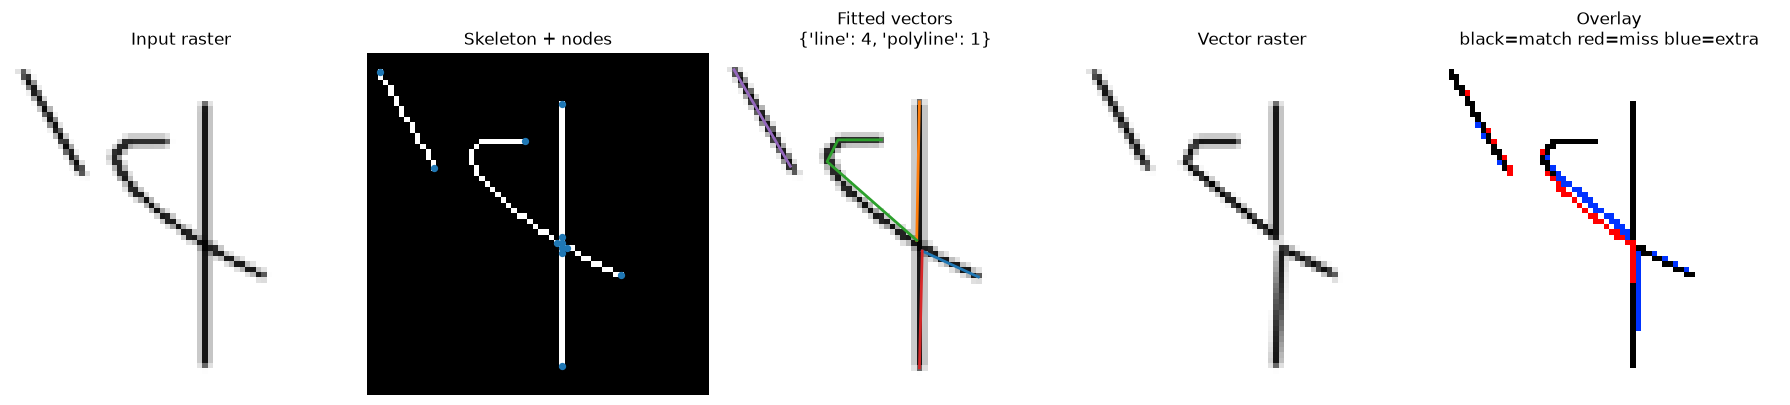

{
  "precision_tol": 0.8881118881118881,
  "recall_tol": 0.9,
  "f1_tol": 0.8940164254986313,
  "iou_exact": 0.5337078651685393,
  "dice_exact": 0.6959706959706959,
  "mse": 0.011254021897912025,
  "true_pixels": 130,
  "pred_pixels": 143
}
{
  "line": 4,
  "polyline": 1
}


In [8]:
def get_sample_from_existing_data_or_generate(sample_index=0):
    if "X_test" in globals():
        return normalise_image(X_test[sample_index]), None

    image, truth = generate_mixed_sample(IMG_SIZE, LINE_WIDTH)
    return image, truth


def plot_primitives_on_axis(ax, primitives):
    for primitive in primitives:
        if primitive["type"] == "line":
            ax.plot(
                [primitive["x1"], primitive["x2"]],
                [primitive["y1"], primitive["y2"]],
                linewidth=2,
                label="line",
            )

        elif primitive["type"] == "arc":
            cx = primitive["cx"]
            cy = primitive["cy"]
            radius = primitive["radius"]
            start = primitive["start_angle"]
            end = primitive["end_angle"]
            angles = np.linspace(start, end, 100)
            xs = cx + radius * np.cos(angles)
            ys = cy + radius * np.sin(angles)
            ax.plot(xs, ys, linewidth=2, label="arc")

        elif primitive["type"] == "polyline":
            points = np.asarray(primitive["points"])
            ax.plot(points[:, 0], points[:, 1], linewidth=2, label="polyline")


def show_mixed_vectorisation_result(sample_index=0, params=None):
    if params is None:
        params = DEFAULT_VECTORISE_PARAMS

    image, truth = get_sample_from_existing_data_or_generate(sample_index)
    result = vectorise_mixed_image(image, img_size=IMG_SIZE, params=params, return_stages=True)

    raster = result["raster"]
    primitives = result["primitives"]
    metrics = result["metrics"]
    skeleton = result["skeleton"]
    nodes = result["nodes"]

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))

    axes[0].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Input raster")
    axes[0].axis("off")

    axes[1].imshow(skeleton, cmap="gray")
    axes[1].scatter([x for y, x in nodes], [y for y, x in nodes], s=18)
    axes[1].set_title("Skeleton + nodes")
    axes[1].axis("off")

    axes[2].imshow(image, cmap="gray", vmin=0, vmax=1)
    plot_primitives_on_axis(axes[2], primitives)
    axes[2].set_title(f"Fitted vectors\n{primitive_summary(primitives)}")
    axes[2].set_xlim(0, IMG_SIZE - 1)
    axes[2].set_ylim(IMG_SIZE - 1, 0)
    axes[2].axis("off")

    axes[3].imshow(raster, cmap="gray", vmin=0, vmax=1)
    axes[3].set_title("Vector raster")
    axes[3].axis("off")

    overlay = make_overlay(image, raster)
    axes[4].imshow(overlay)
    axes[4].set_title("Overlay\nblack=match red=miss blue=extra")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()

    print(json.dumps(metrics, indent=2))
    print(json.dumps(primitive_summary(primitives), indent=2))

    return result


result = show_mixed_vectorisation_result(sample_index=0)


## Tune parameters

The most useful parameters are usually:

```text
line_rmse_max       smaller = fewer paths treated as straight lines
arc_rmse_max        smaller = stricter circular arcs
polyline_tolerance  larger = simpler/fewer polyline points
snap_distance       larger = more endpoint snapping
```

In [9]:
def test_parameter_sets(sample_count=20):
    parameter_sets = []

    for line_rmse in [0.45, 0.65, 0.85]:
        for arc_rmse in [0.60, 0.80, 1.00]:
            for poly_tol in [0.8, 1.2, 1.8]:
                params = dict(DEFAULT_VECTORISE_PARAMS)
                params["line_rmse_max"] = line_rmse
                params["arc_rmse_max"] = arc_rmse
                params["polyline_tolerance"] = poly_tol
                parameter_sets.append(params)

    rows = []

    for param_index, params in enumerate(parameter_sets):
        metric_rows = []
        primitive_counts = []

        for _ in range(sample_count):
            image, _ = generate_mixed_sample(IMG_SIZE, LINE_WIDTH)
            result = vectorise_mixed_image(image, img_size=IMG_SIZE, params=params, return_stages=False)
            metric_rows.append(result["metrics"])
            primitive_counts.append(len(result["primitives"]))

        rows.append({
            "param_index": param_index,
            "line_rmse_max": params["line_rmse_max"],
            "arc_rmse_max": params["arc_rmse_max"],
            "polyline_tolerance": params["polyline_tolerance"],
            "mean_f1_tol": float(np.mean([m["f1_tol"] for m in metric_rows])),
            "mean_precision_tol": float(np.mean([m["precision_tol"] for m in metric_rows])),
            "mean_recall_tol": float(np.mean([m["recall_tol"] for m in metric_rows])),
            "mean_dice_exact": float(np.mean([m["dice_exact"] for m in metric_rows])),
            "mean_primitive_count": float(np.mean(primitive_counts)),
        })

    rows = sorted(rows, key=lambda row: row["mean_f1_tol"], reverse=True)
    return rows


parameter_results = test_parameter_sets(sample_count=10)
parameter_results[:10]


C:\Users\elmak\AppData\Local\Temp\ipykernel_3692\3382331190.py:53: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  true_dilated = binary_dilation(true_fg, selem)
C:\Users\elmak\AppData\Local\Temp\ipykernel_3692\3382331190.py:54: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  pred_dilated = binary_dilation(pred_fg, selem)


[{'param_index': 25,
  'line_rmse_max': 0.85,
  'arc_rmse_max': 1.0,
  'polyline_tolerance': 1.2,
  'mean_f1_tol': 0.986588684796916,
  'mean_precision_tol': 0.9972027972027971,
  'mean_recall_tol': 0.9766309531004909,
  'mean_dice_exact': 0.8284305507578722,
  'mean_primitive_count': 4.1},
 {'param_index': 2,
  'line_rmse_max': 0.45,
  'arc_rmse_max': 0.6,
  'polyline_tolerance': 1.8,
  'mean_f1_tol': 0.98072023684983,
  'mean_precision_tol': 1.0,
  'mean_recall_tol': 0.9628970809414842,
  'mean_dice_exact': 0.8138665145913517,
  'mean_primitive_count': 3.9},
 {'param_index': 21,
  'line_rmse_max': 0.85,
  'arc_rmse_max': 0.8,
  'polyline_tolerance': 0.8,
  'mean_f1_tol': 0.9796434915075647,
  'mean_precision_tol': 0.9989010989010989,
  'mean_recall_tol': 0.9621690269995478,
  'mean_dice_exact': 0.8180601854588809,
  'mean_primitive_count': 4.6},
 {'param_index': 17,
  'line_rmse_max': 0.65,
  'arc_rmse_max': 1.0,
  'polyline_tolerance': 1.8,
  'mean_f1_tol': 0.9791347476897194,
  'me

## Export vector primitives

This stores the vector output as JSON. The structure is simple enough to reuse later as pseudo-labels for a neural model.

In [10]:
def export_primitives_to_json(primitives, output_path="mixed_vector_output.json"):
    output_path = Path(output_path)

    with output_path.open("w", encoding="utf-8") as f:
        json.dump(primitives, f, indent=2)

    return output_path


def vectorise_and_export_sample(sample_index=0, output_path="mixed_vector_output.json"):
    image, _ = get_sample_from_existing_data_or_generate(sample_index)
    result = vectorise_mixed_image(image, img_size=IMG_SIZE, return_stages=False)
    return export_primitives_to_json(result["primitives"], output_path=output_path)


export_path = export_primitives_to_json(result["primitives"], "mixed_vector_output.json")
print(f"Saved: {export_path.resolve()}")


Saved: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\mixed_vector_output.json


## Optional: batch pseudo-label export

Use this if you want to create labels from a batch of raster images and train a neural model later.

In [11]:
def create_pseudo_labels_from_images(images, params=None, output_path="mixed_curve_pseudo_labels.json"):
    if params is None:
        params = DEFAULT_VECTORISE_PARAMS

    all_labels = []

    for index, image in enumerate(images):
        result = vectorise_mixed_image(image, img_size=IMG_SIZE, params=params, return_stages=False)
        all_labels.append({
            "index": index,
            "primitives": result["primitives"],
            "metrics": result["metrics"],
        })

    output_path = Path(output_path)

    with output_path.open("w", encoding="utf-8") as f:
        json.dump(all_labels, f, indent=2)

    return all_labels, output_path


# Example for your existing test data, if X_test exists:
# labels, path = create_pseudo_labels_from_images(X_test[:100])
# print(path)


## Notes for improving results

If curves are being classified as lines, reduce `line_rmse_max`.

If circular arcs are being classified as polylines, increase `arc_rmse_max` slightly or reduce `arc_min_span_degrees`.

If the output contains too many tiny fragments, increase `min_path_points` and `min_primitive_length`.

If intersections are not clean, increase `snap_distance` slightly, for example from `1.5` to `2.0`.